In [84]:
import pandas as pd

In [114]:
# Baca file CSV
df = pd.read_csv("data_news/merged_with_vector_same_day.csv")
df_new = df[['date_only', 'vec_judul','Status']].copy()
df_new['date_only'] = pd.to_datetime(df_new['date_only'], errors='coerce')
df_new['day'] = (df_new['date_only'].dt.dayofweek + 1 ) / 10 # jadi Senin=1, Minggu=7
df_new = df_new[['day', 'vec_judul','Status']]

In [115]:
df_new

,day,vec_judul,Status
0,0.1,-0.27646404504776 0.19038879871368408 0.998546...,GOOD
1,0.1,-0.566576361656189 0.07860100269317627 0.99011...,GOOD
2,0.2,-0.3197835683822632 0.2006453275680542 0.99844...,BAD
3,0.2,-0.5011534690856934 0.17542198300361633 0.9920...,GOOD
4,0.5,-0.46352627873420715 0.1881604939699173 0.9975...,GOOD
...,...,...,...
17378,0.3,-0.5195209383964539 0.2741708755493164 0.99796...,GOOD
17379,0.3,-0.30753302574157715 0.02589549869298935 0.999...,GOOD
17380,0.3,-0.5050747394561768 0.1164725124835968 0.98607...,GOOD
17381,0.3,-0.4769655764102936 0.15850597620010376 0.9909...,GOOD


In [116]:
print(df_new.dtypes)

day          float64
vec_judul     object
Status        object
dtype: object


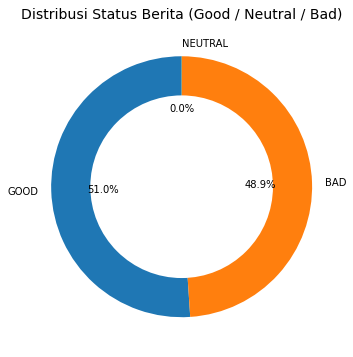

In [117]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kategori status
status_counts = df_new['Status'].value_counts()

# Buat diagram donat
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # Membuat donat (lubang di tengah)
)

# Tambahkan lingkaran putih di tengah
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Judul
plt.title('Distribusi Status Berita (Good / Neutral / Bad)', fontsize=14)

# Tampilkan grafik
plt.show()


In [118]:
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset
import ast
import numpy as np


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class IndoBertDataset(Dataset):
    def __init__(self, df, labels, device=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.device = device

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Ambil vector ---
        vec = row["vec_judul"]

        # Jika string format numpy array -> ubah ke np.array
        if isinstance(vec, str):
            vec = np.fromstring(vec.strip("[]"), sep=" ")

        if isinstance(vec, np.ndarray):
            x = torch.from_numpy(vec).float()
        else:
            x = torch.tensor(vec, dtype=torch.float)

        # --- Normalisasi ke 0..1 ---
        if x.numel() > 0:  # pastikan tidak kosong
            min_val, max_val = x.min(), x.max()
            if (max_val - min_val) > 0:  # hindari div 0
                x = (x - min_val) / (max_val - min_val)

        # --- Tambahkan kolom day ---
        if "day" in row:
            day_val = float(row["day"])
            day_tensor = torch.tensor([day_val], dtype=torch.float)
            x = torch.cat([x, day_tensor], dim=0)

        # --- Ambil target y ---
        y = torch.tensor([float(row[label]) for label in self.labels], dtype=torch.float)

        if self.device:
            x = x.to(self.device)
            y = y.to(self.device)

        return x, y

In [119]:
label = pd.get_dummies(df_new['Status']).astype(int)
df_new = pd.concat([df_new, label], axis=1)
df_new

,day,vec_judul,Status,BAD,GOOD,NEUTRAL
0,0.1,-0.27646404504776 0.19038879871368408 0.998546...,GOOD,0,1,0
1,0.1,-0.566576361656189 0.07860100269317627 0.99011...,GOOD,0,1,0
2,0.2,-0.3197835683822632 0.2006453275680542 0.99844...,BAD,1,0,0
3,0.2,-0.5011534690856934 0.17542198300361633 0.9920...,GOOD,0,1,0
4,0.5,-0.46352627873420715 0.1881604939699173 0.9975...,GOOD,0,1,0
...,...,...,...,...,...,...
17378,0.3,-0.5195209383964539 0.2741708755493164 0.99796...,GOOD,0,1,0
17379,0.3,-0.30753302574157715 0.02589549869298935 0.999...,GOOD,0,1,0
17380,0.3,-0.5050747394561768 0.1164725124835968 0.98607...,GOOD,0,1,0
17381,0.3,-0.4769655764102936 0.15850597620010376 0.9909...,GOOD,0,1,0


In [120]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_new, test_size=0.3, random_state=42,shuffle=True)


from torch.utils.data import DataLoader
labels =['BAD', 'GOOD']
train_dataset = IndoBertDataset(train_df, labels, device=device)
test_dataset = IndoBertDataset(test_df, labels, device=device)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#train_dataset.__getitem__(1)
len(test_dataset[0][1])
#train_dataset.__len__()
test_dataset[0]

(tensor([1.8560e-01, 5.5214e-01, 9.9955e-01, 9.9952e-01, 4.1628e-01, 3.0369e-05,
         7.0095e-01, 3.9329e-01, 9.9544e-01, 4.0334e-02, 1.0000e+00, 6.8900e-01,
         2.8106e-03, 1.6366e-01, 3.5271e-01, 2.4362e-03, 1.7127e-01, 5.6982e-01,
         8.6762e-02, 5.2743e-02, 8.9895e-01, 9.9667e-01, 8.3046e-01, 9.9988e-01,
         9.4851e-01, 6.3873e-03, 5.5293e-01, 9.3092e-03, 9.9990e-01, 4.8341e-01,
         7.9270e-01, 9.6860e-01, 3.4467e-01, 7.8737e-01, 1.7957e-03, 9.9900e-01,
         2.0515e-01, 6.9855e-01, 1.9606e-01, 4.2255e-01, 9.0064e-01, 8.0551e-01,
         8.9780e-01, 9.3221e-01, 4.2597e-01, 2.8814e-01, 1.1057e-01, 9.2638e-01,
         9.5887e-01, 7.3988e-01, 9.6449e-01, 9.9937e-01, 8.8726e-01, 7.6762e-01,
         3.1653e-01, 5.6358e-01, 9.9970e-01, 1.3207e-01, 9.9972e-01, 9.8828e-01,
         6.6361e-01, 6.6791e-01, 6.8311e-01, 7.6938e-01, 9.9673e-01, 9.8456e-01,
         6.9357e-04, 9.8023e-01, 3.7250e-01, 9.7860e-03, 6.7444e-01, 6.9745e-01,
         2.9721e-01, 8.3945e

In [122]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_dim"      : len(test_dataset[0][0]),
    "hidden_dims"    : [128,64],
    "output_dim"     : len(test_dataset[0][1]),
    "dropout"        : 0.2,
    "activation"     : "relu",
    "early_stop_patience" : 10,
    "col_target"     : ['BAD', 'GOOD'],
    "feature_cols"   : ['vec_judul'],
})
config

Config(activation=relu, col_target=['BAD', 'GOOD'], dropout=0.2, early_stop_patience=10, feature_cols=['vec_judul'], hidden_dims=[128, 64], input_dim=769, labels=['BAD', 'GOOD'], output_dim=2, threshold=0.5)

In [124]:
from class_lib import MultiLabel1DClassifier
from torch import optim, nn
from jcopdl.callback import Callback
root_folder = "multi-label-clasification"
#Model
model = MultiLabel1DClassifier(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation).to(device)

#Criterion
criterion = nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=1.0)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:02<00:00, 33.69it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6938 │ 0.6930 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4975 │ 0.4846 │ │  BAD  │  0.5189  │
│ Subset Accuracy  │ 0.1648 │ 0.3091 │ │ GOOD  │  0.5120  │
│ Micro F1         │ 0.6165 │ 0.5967 │ └───────┴──────────┘
│ Macro F1         │ 0.6159 │ 0.5696 │                     
│ Overall Accuracy │ 0.5025 │ 0.5154 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6938 | Test_cost  = 0.6930 | Train_score = 0.5025 | Test_score = 0.5154 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6911 | Test_cost  = 0.6907 | Train_score = 0.5322 | Test_score = 0.5435 |


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:01<00:00, 41.52it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6911 │ 0.6904 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4668 │ 0.4567 │ │  BAD  │  0.5434  │
│ Subset Accuracy  │ 0.4316 │ 0.5093 │ │ GOOD  │  0.5432  │
│ Micro F1         │ 0.5512 │ 0.5566 │ └───────┴──────────┘
│ Macro F1         │ 0.5374 │ 0.5336 │                     
│ Overall Accuracy │ 0.5332 │ 0.5433 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6911 | Test_cost  = 0.6904 | Train_score = 0.5332 | Test_score = 0.5433 |


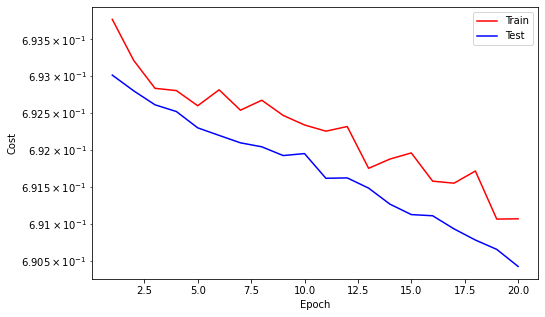

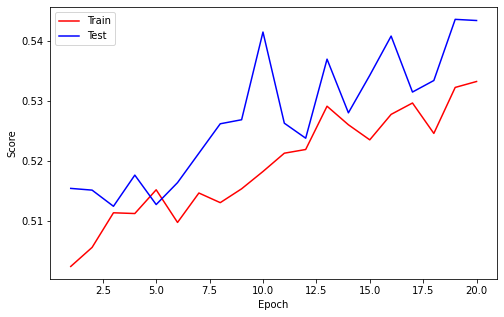

==> EarlyStop patience =  1 | Best test_score: 0.5435


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:02<00:00, 39.82it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6909 │ 0.6904 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4719 │ 0.4582 │ │  BAD  │  0.5404  │
│ Subset Accuracy  │ 0.4412 │ 0.4848 │ │ GOOD  │  0.5432  │
│ Micro F1         │ 0.5396 │ 0.5665 │ └───────┴──────────┘
│ Macro F1         │ 0.5205 │ 0.5570 │                     
│ Overall Accuracy │ 0.5281 │ 0.5418 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6909 | Test_cost  = 0.6904 | Train_score = 0.5281 | Test_score = 0.5418 |
==> EarlyStop patience =  2 | Best test_score: 0.5435


...


Epoch    39
Train_cost  = 0.6885 | Test_cost  = 0.6875 | Train_score = 0.5450 | Test_score = 0.5398 |
==> EarlyStop patience =  3 | Best test_score: 0.5476


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:01<00:00, 41.15it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6888 │ 0.6873 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4613 │ 0.4526 │ │  BAD  │  0.5478  │
│ Subset Accuracy  │ 0.4983 │ 0.5375 │ │ GOOD  │  0.5469  │
│ Micro F1         │ 0.5417 │ 0.5512 │ └───────┴──────────┘
│ Macro F1         │ 0.5334 │ 0.5410 │                     
│ Overall Accuracy │ 0.5387 │ 0.5474 │                     
└──────────────────┴────────┴────────┘


Epoch    40
Train_cost  = 0.6888 | Test_cost  = 0.6873 | Train_score = 0.5387 | Test_score = 0.5474 |


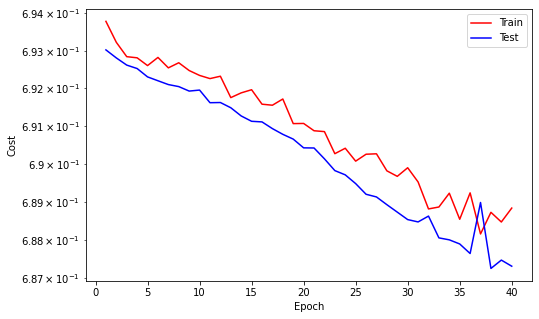

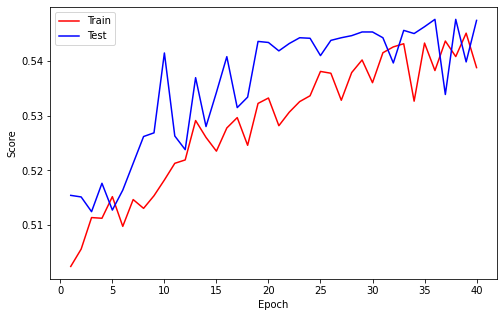

==> EarlyStop patience =  4 | Best test_score: 0.5476


─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:01<00:00, 41.72it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6881 │ 0.6872 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4549 │ 0.4581 │ │  BAD  │  0.5427  │
│ Subset Accuracy  │ 0.5068 │ 0.5315 │ │ GOOD  │  0.5411  │
│ Micro F1         │ 0.5472 │ 0.5459 │ └───────┴──────────┘
│ Macro F1         │ 0.5392 │ 0.5444 │                     
│ Overall Accuracy │ 0.5451 │ 0.5419 │                     
└──────────────────┴────────┴────────┘


Epoch    41
Train_cost  = 0.6881 | Test_cost  = 0.6872 | Train_score = 0.5451 | Test_score = 0.5419 |
==> EarlyStop patience =  5 | Best test_score: 0.5476


...


Epoch    59
Train_cost  = 0.6867 | Test_cost  = 0.6853 | Train_score = 0.5512 | Test_score = 0.5513 |
==> EarlyStop patience =  3 | Best test_score: 0.5522


─────────────────────────────────────────────────── 🚀 EPOCH 60 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:02<00:00, 39.75it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6860 │ 0.6865 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4491 │ 0.4542 │ │  BAD  │  0.5459  │
│ Subset Accuracy  │ 0.5218 │ 0.5404 │ │ GOOD  │  0.5457  │
│ Micro F1         │ 0.5531 │ 0.5480 │ └───────┴──────────┘
│ Macro F1         │ 0.5475 │ 0.4917 │                     
│ Overall Accuracy │ 0.5509 │ 0.5458 │                     
└──────────────────┴────────┴────────┘


Epoch    60
Train_cost  = 0.6860 | Test_cost  = 0.6865 | Train_score = 0.5509 | Test_score = 0.5458 |


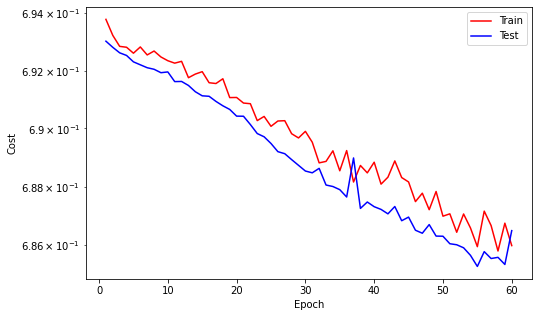

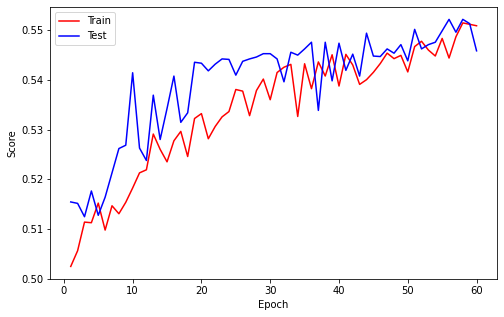

==> EarlyStop patience =  4 | Best test_score: 0.5522


─────────────────────────────────────────────────── 🚀 EPOCH 61 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:01<00:00, 41.10it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6865 │ 0.6849 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4491 │ 0.4462 │ │  BAD  │  0.5536  │
│ Subset Accuracy  │ 0.5224 │ 0.5432 │ │ GOOD  │  0.5540  │
│ Micro F1         │ 0.5571 │ 0.5584 │ └───────┴──────────┘
│ Macro F1         │ 0.5457 │ 0.5501 │                     
│ Overall Accuracy │ 0.5509 │ 0.5538 │                     
└──────────────────┴────────┴────────┘


Epoch    61
Train_cost  = 0.6865 | Test_cost  = 0.6849 | Train_score = 0.5509 | Test_score = 0.5538 |


...


Epoch    79
Train_cost  = 0.6839 | Test_cost  = 0.6826 | Train_score = 0.5590 | Test_score = 0.5669 |
==> EarlyStop patience =  2 | Best test_score: 0.5675


─────────────────────────────────────────────────── 🚀 EPOCH 80 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:01<00:00, 41.49it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6825 │ 0.6835 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4379 │ 0.4428 │ │  BAD  │  0.5580  │
│ Subset Accuracy  │ 0.5422 │ 0.5500 │ │ GOOD  │  0.5565  │
│ Micro F1         │ 0.5629 │ 0.5599 │ └───────┴──────────┘
│ Macro F1         │ 0.5554 │ 0.5596 │                     
│ Overall Accuracy │ 0.5621 │ 0.5572 │                     
└──────────────────┴────────┴────────┘


Epoch    80
Train_cost  = 0.6825 | Test_cost  = 0.6835 | Train_score = 0.5621 | Test_score = 0.5572 |


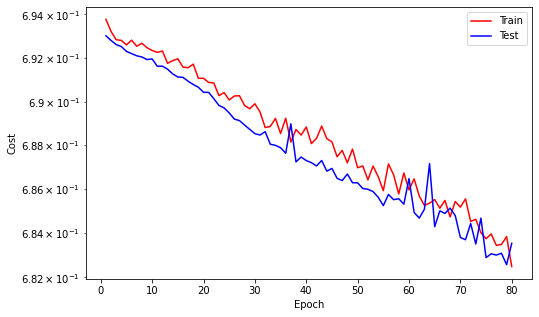

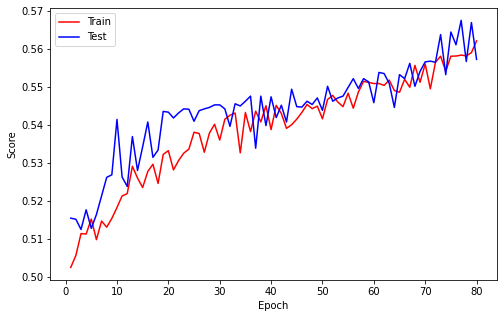

==> EarlyStop patience =  3 | Best test_score: 0.5675


─────────────────────────────────────────────────── 🚀 EPOCH 81 ───────────────────────────────────────────────────

test: 100%|██████████| 82/82 [00:02<00:00, 40.66it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6835 │ 0.6831 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4418 │ 0.4415 │ │  BAD  │  0.5559  │
│ Subset Accuracy  │ 0.5384 │ 0.5375 │ │ GOOD  │  0.5611  │
│ Micro F1         │ 0.5593 │ 0.5676 │ └───────┴──────────┘
│ Macro F1         │ 0.5517 │ 0.5668 │                     
│ Overall Accuracy │ 0.5582 │ 0.5585 │                     
└──────────────────┴────────┴────────┘


Epoch    81
Train_cost  = 0.6835 | Test_cost  = 0.6831 | Train_score = 0.5582 | Test_score = 0.5585 |
==> EarlyStop patience =  4 | Best test_score: 0.5675


...

              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6830 │ 0.6819 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4394 │ 0.4314 │ │  BAD  │  0.5684  │
│ Subset Accuracy  │ 0.5434 │ 0.5636 │ │ GOOD  │  0.5689  │
│ Micro F1         │ 0.5615 │ 0.5679 │ └───────┴──────────┘
│ Macro F1         │ 0.5535 │ 0.5630 │                     
│ Overall Accuracy │ 0.5606 │ 0.5686 │                     
└──────────────────┴────────┴────────┘


Epoch    85
Train_cost  = 0.6830 | Test_cost  = 0.6819 | Train_score = 0.5606 | Test_score = 0.5686 |
==> EarlyStop patience =  1 | Best test_score: 0.5704


─────────────────────────────────────────────────── 🚀 EPOCH 86 ───────────────────────────────────────────────────

test:  15%|█▍        | 12/82 [00:00<00:01, 38.12it/s]


KeyboardInterrupt: 

In [125]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

In [101]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, ['BAD', 'GOOD'],criterion, device, config.threshold)

       📊 Evaluasi Model            🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓      Accuracy      
┃ Metrik              ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Akurasi ┃
│ 🔹 Overall Accuracy │ 0.5747 │ ┡━━━━━━━╇━━━━━━━━━┩
│ ✅ Subset  Accuracy │ 0.5745 │ │  BAD  │ 0.5747  │
│ 💥 Loss (avg)       │ 0.6767 │ │ GOOD  │ 0.5747  │
│ 📉 Hamming Loss     │ 0.4253 │ └───────┴─────────┘
│ ⚖️  Micro F1-score   │ 0.5746 │                    
│ 📈 Macro F1-score   │ 0.5604 │                    
└─────────────────────┴────────┘

In [102]:
hsl['df'].head(100)

,Target,Prediksi,Benar (%)
0,"[0.0, 1.0]","[0.0, 1.0]",100.0
1,"[0.0, 1.0]","[1.0, 0.0]",0.0
2,"[0.0, 1.0]","[1.0, 0.0]",0.0
3,"[0.0, 1.0]","[0.0, 1.0]",100.0
4,"[1.0, 0.0]","[0.0, 1.0]",0.0
...,...,...,...
95,"[0.0, 1.0]","[0.0, 1.0]",100.0
96,"[1.0, 0.0]","[1.0, 0.0]",100.0
97,"[0.0, 1.0]","[0.0, 1.0]",100.0
98,"[1.0, 0.0]","[1.0, 0.0]",100.0
